In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Training Samples:", len(x_train))
print("Testing Samples:", len(x_test))
# Reshape
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test = x_test.reshape(-1,28,28,1)/255.0
# One-hot encoding
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)
# CNN Model
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])
# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Train
model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test,y_test)
)
# Evaluate
loss, accuracy = model.evaluate(x_test,y_test)
print("Test Accuracy =", accuracy)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training Samples: 60000
Testing Samples: 10000


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9547 - loss: 0.1533 - val_accuracy: 0.9786 - val_loss: 0.0698
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9841 - loss: 0.0515 - val_accuracy: 0.9821 - val_loss: 0.0544
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9894 - loss: 0.0330 - val_accuracy: 0.9856 - val_loss: 0.0414
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9931 - loss: 0.0221 - val_accuracy: 0.9826 - val_loss: 0.0551
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.9956 - loss: 0.0143 - val_accuracy: 0.9845 - val_loss: 0.0573
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9845 - loss: 0.0573
Test Accuracy = 0.984499990940094


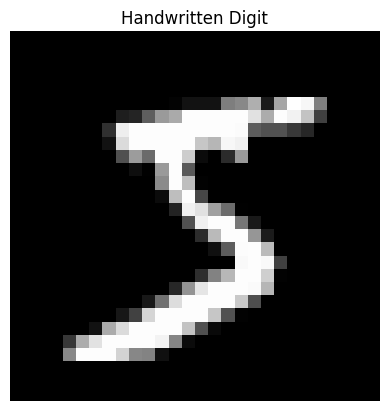

In [2]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0].reshape(28,28), cmap='gray')
plt.title("Handwritten Digit")
plt.axis('off')
plt.show()

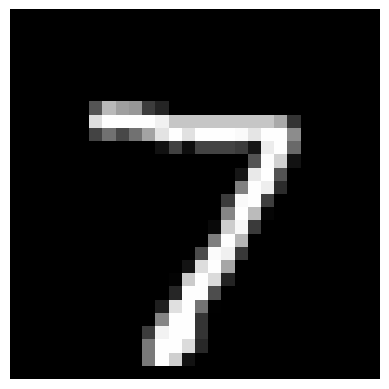

Predicted Digit: 7
Actual Digit: 7


In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.axis('off')
plt.show()

prediction = model.predict(x_test[0].reshape(1,28,28,1), verbose=0)

print("Predicted Digit:", np.argmax(prediction))
print("Actual Digit:", np.argmax(y_test[0]))

In [4]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[ 974    1    0    0    0    0    3    1    1    0]
 [   0 1132    0    0    0    1    1    1    0    0]
 [   4    5 1007    1    2    0    2    5    5    1]
 [   0    0    0  987    0   18    0    2    3    0]
 [   0    2    0    0  973    0    1    1    0    5]
 [   1    0    0    1    0  888    2    0    0    0]
 [   1    3    0    0    1    5  946    0    2    0]
 [   1    5    8    0    0    1    0 1008    1    4]
 [   2    1    0    0    0    6    1    1  960    3]
 [   3    6    0    2    6   12    0    4    6  970]]


In [6]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test,y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9964 - loss: 0.0111 - val_accuracy: 0.9823 - val_loss: 0.0660
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9977 - loss: 0.0075 - val_accuracy: 0.9832 - val_loss: 0.0564
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9981 - loss: 0.0059 - val_accuracy: 0.9852 - val_loss: 0.0596
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9984 - loss: 0.0051 - val_accuracy: 0.9867 - val_loss: 0.0539
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9984 - loss: 0.0047 - val_accuracy: 0.9853 - val_loss: 0.0608


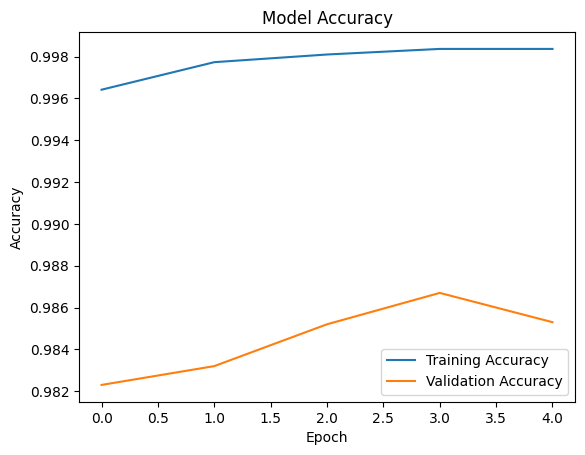

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy','Validation Accuracy'])

plt.show()